In [1]:
import os
try:
    path_initialized
except NameError:
    path_initialized = True
    os.chdir('..')

import numpy as np
from sympy.abc import x, y

# from qldpc import codes
import networkx as nx
import matplotlib.pyplot as plt

import src.device as device
import src.plotting as plotter
from src.RotatedSurfaceCode import RotatedSurfaceCode
from src.HGPCode import HGPCode
from src.QECCode import TestCode

In [2]:
dev = device.UnitCellDevice(2,1, device.hardware_params(1e-3), debug=True)
code = TestCode(2, 1)
code.add_row_check(0)
code.add_row_check(0)

data_coords = {0: (0,0), 1: (1,0)}
sched = dev.compile_QEC_schedule(
    code,
    data_coords,
    [],# code.check_cx_layers,
    rounds=1,
    use_highways=True,
    refocus_shuttle_noise=False,
)

[2, 3]
2 (1, 0) [(1, 0), (0, 0)]
POP (1, 0, 'READOUT', 0) with cost 1599.0 (500 + 1599.0)
	ADD (1, 0, 'INTERACTION_ZONE', 0) FROM (1, 0, 'READOUT', 0) WITH COST 100
		estimated cost: 2099.0
	ADD (1, 0, 'SHUTTLE_INTERSECTION', 0) FROM (1, 0, 'READOUT', 0) WITH COST 100
		estimated cost: 2199.0
POP (1, 0, 'INTERACTION_ZONE', 0) with cost 2099.0 (600 + 1499.0)
	ADD (1, 0, 'READOUT', 0) FROM (1, 0, 'INTERACTION_ZONE', 0) WITH COST 100
		talready seen, cost 500, new cost 700
		pass
	ADD (1, 0, 'SHUTTLE_INTERSECTION', 0) FROM (1, 0, 'INTERACTION_ZONE', 0) WITH COST 100
		talready seen, cost 600, new cost 700
		pass
	ADD (1, 0, 'INTERACTION_ZONE', 1) FROM (1, 0, 'INTERACTION_ZONE', 0) WITH COST 100
		estimated cost: 2099.0
POP (1, 0, 'INTERACTION_ZONE', 1) with cost 2099.0 (700 + 1399.0)
	ADD (1, 0, 'READOUT', 1) FROM (1, 0, 'INTERACTION_ZONE', 1) WITH COST 100
		estimated cost: 2199.0
	ADD (1, 0, 'SHUTTLE_INTERSECTION', 1) FROM (1, 0, 'INTERACTION_ZONE', 1) WITH COST 100
		estimated cost: 20

In [3]:
for instr,t in zip(sched.instructions, sched.instruction_start_times):
    print(t, instr)

0 Instantiate(duration=500, error=0.001, qubits=[0, 1], cell_coords=[(0, 0), (1, 0)])
500 EmplaceDisplace(duration=100, error=1e-06, qubit=0, coords=(0, 0), start_component=READOUT, end_component=INTERACTION_ZONE)
500 EmplaceDisplace(duration=100, error=1e-06, qubit=1, coords=(1, 0), start_component=READOUT, end_component=INTERACTION_ZONE)
600 Instantiate(duration=500, error=0.001, qubits=[2, 3], cell_coords=[(1, 0), (0, 0)])
1100 EmplaceDisplace(duration=100, error=1e-06, qubit=2, coords=(1, 0), start_component=READOUT, end_component=INTERACTION_ZONE)
1200 Gate(duration=100, error=0.001, qubits=[1, 2], name=GateName.CX)
1300 EmplaceDisplace(duration=100, error=1e-06, qubit=2, coords=(1, 0), start_component=INTERACTION_ZONE, end_component=SHUTTLE_INTERSECTION)
1400 Shuttle(duration=1000, error=1e-05, qubit=2, start_coords=(1, 0), end_coords=(0, 0))
2400 EmplaceDisplace(duration=100, error=1e-06, qubit=2, coords=(0, 0), start_component=SHUTTLE_INTERSECTION, end_component=INTERACTION_ZON

In [4]:
code.data_coords

[(0, 0), (1, 0)]

In [5]:
frames = sched.get_frames(20)

MovieWriter imagemagick unavailable; using Pillow instead.


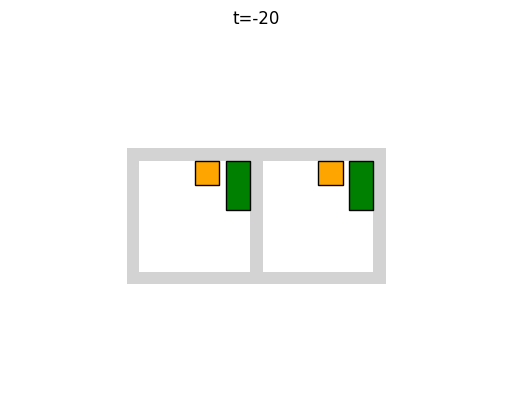

In [6]:
frames = sched.get_frames(20)
# plotter.plot_device_snapshot(dev, code, frames[10])
anim = plotter.animate_device(dev, code, frames, 'anim_test.gif', fps=30)

In [7]:
d = 5
dev = device.UnitCellDevice(d+2, d+2, device.hardware_params(1e-3))
code = RotatedSurfaceCode(d)

data_coords = {q:((code.qubit_coords[q][0]+1)//2, (code.qubit_coords[q][1]+1)//2) for q in code.data_indices}
assert len(set(data_coords.values())) == len(data_coords)
sched = dev.compile_QEC_schedule(
    code,
    data_coords,
    code.check_cx_layers,
    rounds=1,
    use_highways=True,
    refocus_shuttle_noise=False,
)

[25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48]
Optimizing 24 ancilla schedules........................

In [8]:
for instr,t in zip(sched.instructions, sched.instruction_start_times):
    print(t, instr)

0 Instantiate(duration=500, error=0.001, qubits=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24], cell_coords=[(1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (2, 1), (2, 2), (2, 3), (2, 4), (2, 5), (3, 1), (3, 2), (3, 3), (3, 4), (3, 5), (4, 1), (4, 2), (4, 3), (4, 4), (4, 5), (5, 1), (5, 2), (5, 3), (5, 4), (5, 5)])
500 EmplaceDisplace(duration=100, error=1e-06, qubit=0, coords=(1, 1), start_component=READOUT, end_component=INTERACTION_ZONE)
500 EmplaceDisplace(duration=100, error=1e-06, qubit=1, coords=(1, 2), start_component=READOUT, end_component=INTERACTION_ZONE)
500 EmplaceDisplace(duration=100, error=1e-06, qubit=2, coords=(1, 3), start_component=READOUT, end_component=INTERACTION_ZONE)
500 EmplaceDisplace(duration=100, error=1e-06, qubit=3, coords=(1, 4), start_component=READOUT, end_component=INTERACTION_ZONE)
500 EmplaceDisplace(duration=100, error=1e-06, qubit=4, coords=(1, 5), start_component=READOUT, end_component=INTERACTION_ZONE)
500 Em

MovieWriter imagemagick unavailable; using Pillow instead.


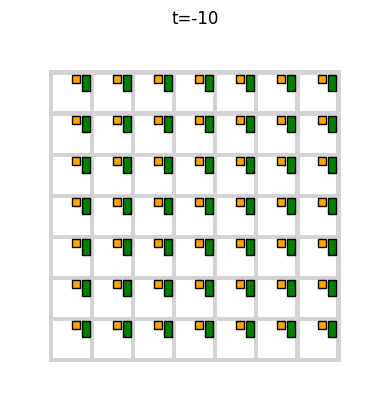

In [9]:
frames = sched.get_frames(10)
# plotter.plot_device_snapshot(dev, code, frames[50])
anim = plotter.animate_device(dev, code, frames, 'anim_surface.gif', fps=30)

In [23]:
code_hgp = HGPCode.simplex_code(r=3)

num_qubits = len(code_hgp.data_indices + code_hgp.X_ancilla_indices + code_hgp.Z_ancilla_indices)
s = int(np.sqrt(len(code_hgp.data_indices)//2))
available_coords = set((x,y) for x in range(1, 2*s+1) for y in range(1, s+1))
data_coords_hgp = {}
for i,d in enumerate(code_hgp.data_indices):
    # coords = min(available_coords, key=lambda c: (c[0] - s/2)**2 + (c[1] - s/2)**2)
    # data_coords_hgp[d] = coords
    # available_coords.remove(coords)
    if d < s**2:
        data_coords_hgp[d] = (d//s+1, d%s+1)
    else:
        dd = d-s**2
        data_coords_hgp[d] = (s + dd%s+1, dd//s+1)

dev = device.UnitCellDevice(2*s+2, s+2, device.hardware_params(1e-3))

sched = dev.compile_QEC_schedule(
    code_hgp,
    data_coords_hgp,
    [],
    rounds=1,
    use_highways=True,
    refocus_shuttle_noise=False,
)

8
8
[98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195]
Optimizing 98 ancilla schedules..................................................................................................

In [24]:
s

7

(0.0, 9.0)

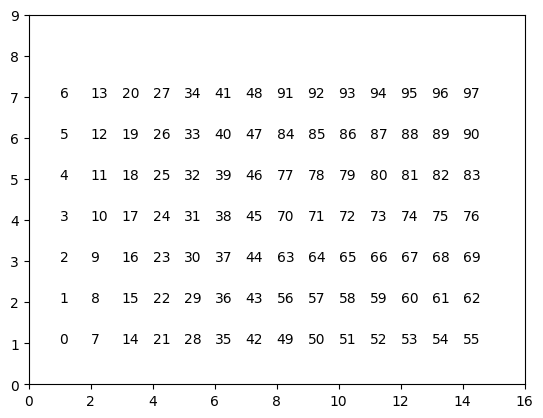

In [25]:
for i,c in data_coords_hgp.items():
    plt.text(c[0], c[1], str(i))
plt.xlim(0, 2*s+2)
plt.ylim(0, s+2)

Need ancilla qubits to be able to decide when and where they start the schedule. Maybe allow free move-anywhere-and-wait action that would be used to set the initialization spot? The wait would be allowed even in a blocked interval, but the end of the wait is an initialization that must be in an available interval.

Also need to let CX order be free



In [26]:
sched.total_duration()

127550

MovieWriter imagemagick unavailable; using Pillow instead.


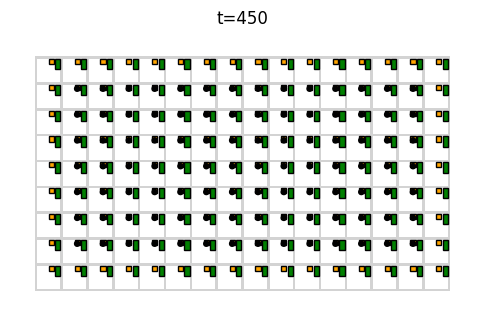

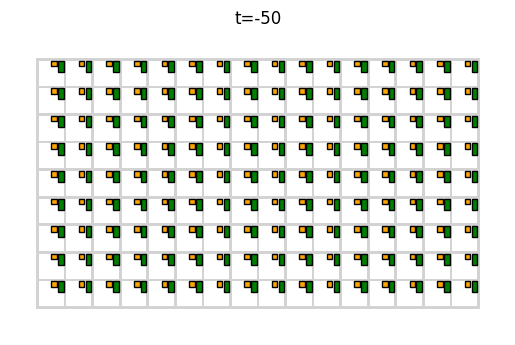

In [27]:
frames = sched.get_frames(50)
plotter.plot_device_snapshot(dev, code_hgp, frames[10])
anim = plotter.animate_device(dev, code_hgp, frames, 'anim_simplex.gif', fps=10)

In [6]:
# construct the second-to-last code in Table 3 of arXiv:2308.07915v2, with code parameters [n, k, d] = [360, 12, <=24]
orders = {x: 30, y: 6}
poly_a = x**9 + y + y**2
poly_b = y**3 + x**25 + x**26
code = codes.BBCode(orders, poly_a, poly_b)

print(code)
print()
print("number of logical qubits:", code.dimension)

# find an upper bound to the code distance with 100 Monte Carlo trials
# 100 trials is likely not enough to reach the upper bound of 24 found by IBM
print("code distance: <=", code.get_distance_bound(num_trials=100))

NameError: name 'codes' is not defined

In [1]:
import stim

In [4]:
circ = stim.Circuit()
circ.append('R', [0, 1])
circ.append('H', [0])
circ.append('CNOT', [0, 1])
circ.append('M', [0, 1])
circ.append('DETECTOR', stim.target_rec(-1), (0.0, 0.0, 0.0))
print(circ)

R 0 1
H 0
CX 0 1
M 0 1
DETECTOR(0, 0, 0) rec[-1]


In [6]:
for instr in circ:
    print(instr.name)

R
H
CX
M
DETECTOR
